# House Price Predictor — Exploratory Data Analysis

This notebook explores the housing dataset before model training: understanding
its shape, distributions, correlations, and data-quality issues (missing values,
duplicates, invalid records).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
%matplotlib inline

df = pd.read_csv("../data/housing.csv")
df.shape

(2015, 8)

## 1. First look at the data

In [2]:
df.head()

,Area,Bedrooms,Bathrooms,Floors,Parking,Age,Location,Price
0,1286,2,2.0,1,0.0,15.0,Chennai,7249000.0
1,2009,2,2.0,1,0.0,5.0,Chennai,11700000.0
2,400,6,6.0,3,1.0,5.0,Pune,4076000.0
3,400,3,2.0,3,2.0,3.0,Hyderabad,2968000.0
4,1300,3,2.0,1,0.0,13.0,Chennai,6441000.0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2015 entries, 0 to 2014
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Area       2015 non-null   int64  
 1   Bedrooms   2015 non-null   int64  
 2   Bathrooms  1974 non-null   float64
 3   Floors     2015 non-null   int64  
 4   Parking    1995 non-null   float64
 5   Age        1985 non-null   float64
 6   Location   2015 non-null   str    
 7   Price      2015 non-null   float64
dtypes: float64(4), int64(3), str(1)
memory usage: 139.3 KB


In [4]:
df.describe()

,Area,Bedrooms,Bathrooms,Floors,Parking,Age,Price
count,2015.000000,2015.000000,1974.000000,2015.000000,1995.000000,1985.000000,2.015000e+03
mean,1490.100248,3.576179,3.112969,2.008933,1.065664,7.090176,1.344152e+07
std,533.802865,1.457450,1.475567,0.822909,1.009582,7.443837,1.147892e+07
min,-1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,2.165000e+06
25%,1123.000000,2.000000,2.000000,1.000000,0.000000,2.000000,8.168500e+06
50%,1482.000000,3.000000,3.000000,2.000000,1.000000,5.000000,1.105600e+07
75%,1844.000000,5.000000,4.000000,3.000000,2.000000,10.000000,1.580350e+07
max,3399.000000,6.000000,6.000000,3.000000,4.000000,45.000000,2.898540e+08


## 2. Data quality checks

In [5]:
print("Missing values per column:")
print(df.isna().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("\nRows with non-positive area:", (df['Area'] <= 0).sum())
print("Rows with non-positive price:", (df['Price'] <= 0).sum())

Missing values per column:
Area          0
Bedrooms      0
Bathrooms    41
Floors        0
Parking      20
Age          30
Location      0
Price         0
dtype: int64

Duplicate rows: 15

Rows with non-positive area: 2
Rows with non-positive price: 0


These issues (missing values, duplicates, invalid rows) are handled in `src/train.py`'s `clean_data()` function before model training.

## 3. Target distribution — Price

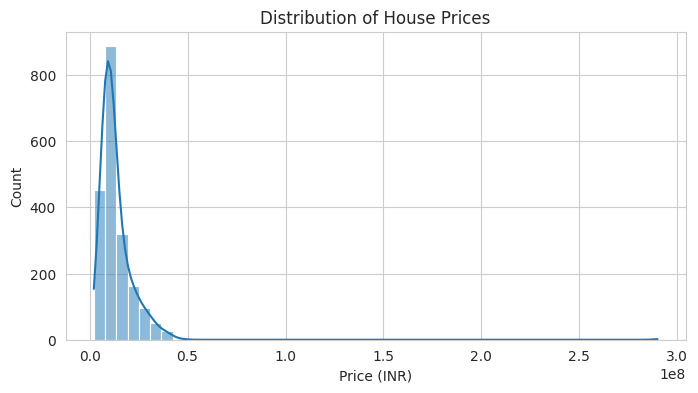

In [6]:
clean_df = df[(df['Area'] > 0) & (df['Price'] > 0)].drop_duplicates()

plt.figure(figsize=(8, 4))
sns.histplot(clean_df['Price'], bins=50, kde=True)
plt.title("Distribution of House Prices")
plt.xlabel("Price (INR)")
plt.show()

## 4. Area vs. Price

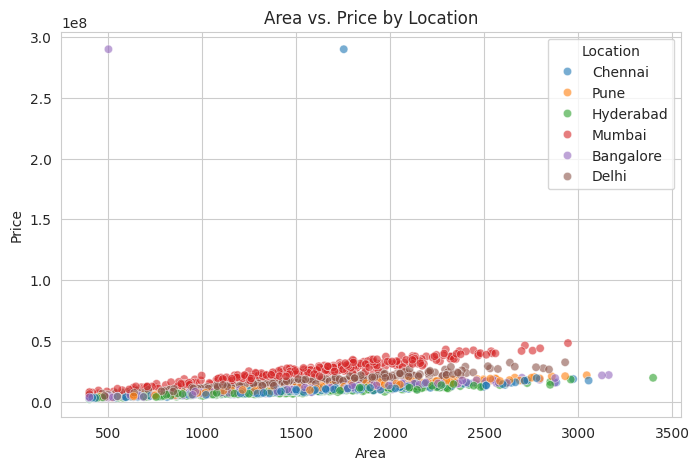

In [7]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=clean_df, x="Area", y="Price", hue="Location", alpha=0.6)
plt.title("Area vs. Price by Location")
plt.show()

## 5. Price by location

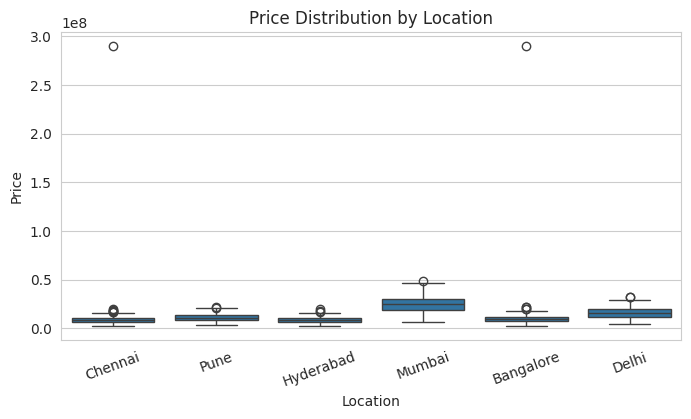

In [8]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=clean_df, x="Location", y="Price")
plt.title("Price Distribution by Location")
plt.xticks(rotation=20)
plt.show()

## 6. Correlation heatmap (numeric features)

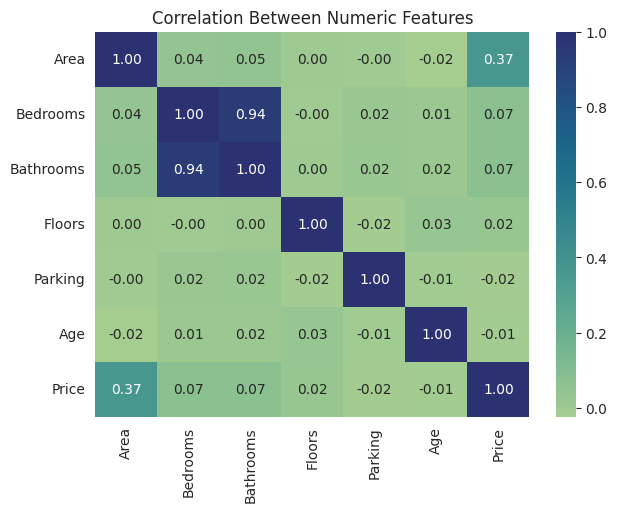

In [9]:
numeric_cols = ["Area", "Bedrooms", "Bathrooms", "Floors", "Parking", "Age", "Price"]
plt.figure(figsize=(7, 5))
sns.heatmap(clean_df[numeric_cols].corr(), annot=True, cmap="crest", fmt=".2f")
plt.title("Correlation Between Numeric Features")
plt.show()

**Observation:** `Area` shows the strongest positive correlation with `Price`, followed by `Bedrooms` and `Bathrooms`. `Age` correlates negatively, consistent with depreciation. These patterns match the assumptions used to generate/model pricing and justify using them as model features. Correlation alone doesn't prove causation, but it's a reasonable feature-relevance signal here.